# Amplitude EOM (Mach-Zehnder Modulator) — Sideband Analysis at 620 nm

## Theory

An amplitude EOM uses a Mach-Zehnder interferometer with an electro-optic crystal. The output field is:

$$E_{\text{out}}(t) = E_0\,\cos\!\bigl(\phi_b + \beta\sin\Omega t\bigr)\;e^{i\omega_0 t}$$

where:
- $\omega_0 = 2\pi c/\lambda$ is the optical carrier frequency  
- $\phi_b = \pi V_{\text{bias}} / (2V_\pi)$ is the **bias phase**  
- $\beta = \pi V_{\text{RF}} / (2V_\pi)$ is the **modulation index**

### Sideband expansion

Writing the cosine in terms of complex exponentials and using the Jacobi–Anger identity:

$$\cos\!\bigl(\phi_b + \beta\sin\Omega t\bigr) = \tfrac{1}{2}\sum_{n} J_n(\beta)\Bigl[e^{i\phi_b} + (-1)^n e^{-i\phi_b}\Bigr]\,e^{in\Omega t}$$

The power of the $n$-th sideband at $\omega_0 + n\Omega$ is:

$$|a_n|^2 = \begin{cases} J_n^2(\beta)\,\cos^2\!\phi_b & n\text{ even (including carrier, }n=0\text{)} \\[4pt] J_n^2(\beta)\,\sin^2\!\phi_b & n\text{ odd} \end{cases}$$

### Key bias points

| Bias point | $\phi_b$ | $V_{\text{bias}}$ | Effect |
|---|---|---|---|
| **Max transmission** | $0$ | $0$ | Only **even**-order sidebands; carrier maximum |
| **Quadrature** | $\pi/4$ | $V_\pi/2$ | All sidebands present, linear AM regime for small $\beta$ |
| **Null / min transmission** | $\pi/2$ | $V_\pi$ | Only **odd**-order sidebands; **carrier suppressed** |

### Two-frequency modulation

With two RF tones $\Omega_1, \Omega_2$ the sideband at $\omega_0 + n\Omega_1 + m\Omega_2$ has power:

$$|a_{n,m}|^2 = \begin{cases} J_n^2(\beta_1)\,J_m^2(\beta_2)\,\cos^2\!\phi_b & n+m\text{ even} \\[4pt] J_n^2(\beta_1)\,J_m^2(\beta_2)\,\sin^2\!\phi_b & n+m\text{ odd} \end{cases}$$

### Factor of 2 vs phase EOM

The **amplitude (MZM)** and **phase** EOM relate $\beta$ to $V_\pi$ differently:

| Modulator | Phase / transfer | $\beta$ in terms of $V_{\text{pp}}$ | $V_{\text{pp}}$ for given $\beta$ |
|-----------|------------------|--------------------------------------|-------------------------------------|
| **Phase EOM** | Phase $\phi = \pi V/V_\pi$ | $\beta = \pi V_{\text{pp}}/(2V_\pi)$ | $V_{\text{pp}} = 2V_\pi\beta/\pi$ |
| **Amplitude EOM (MZM)** | Field $\propto \cos(\pi V/(2V_\pi))$ | $\beta = \pi V_{\text{pp}}/(4V_\pi)$ | $V_{\text{pp}} = 4V_\pi\beta/\pi$ |

The MZM has an extra factor of 2 in the denominator of its transfer function, so for the **same modulation index $\beta$** (and same sideband structure) the MZM requires **twice the RF $V_{\text{pp}}$** as a phase EOM with the same $V_\pi$.

In [8]:
import numpy as np
from scipy.special import jv as besselJ
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
})

c  = 2.998e8          # m/s
lam = 620e-9          # 620 nm
nu_carrier = c / lam  # optical carrier frequency (Hz)

print(f"Carrier wavelength : {lam*1e9:.0f} nm")
print(f"Carrier frequency  : {nu_carrier/1e12:.3f} THz")

Carrier wavelength : 620 nm
Carrier frequency  : 483.548 THz


In [24]:
# ── Factor-of-2 comparison: same β, same V_π ──
V_pi_example = 2.5  # V
beta_example = 1.0

Vpp_phase_EOM = 2 * V_pi_example * beta_example / np.pi
Vpp_MZM       = 4 * V_pi_example * beta_example / np.pi

print("Same modulation index β and same V_π:")
print(f"  V_π = {V_pi_example} V,   β = {beta_example}")
print(f"  Phase EOM:    V_pp = 2 V_π β/π = {Vpp_phase_EOM:.3f} V")
print(f"  Amplitude EOM (MZM): V_pp = 4 V_π β/π = {Vpp_MZM:.3f} V")
print(f"  → MZM needs {Vpp_MZM/Vpp_phase_EOM:.1f}× the RF V_pp for the same sideband structure.")

Same modulation index β and same V_π:
  V_π = 2.5 V,   β = 1.0
  Phase EOM:    V_pp = 2 V_π β/π = 1.592 V
  Amplitude EOM (MZM): V_pp = 4 V_π β/π = 3.183 V
  → MZM needs 2.0× the RF V_pp for the same sideband structure.


## 1. Single-frequency AM-EOM spectrum

The bias point $\phi_b$ controls which sidebands survive:
- **Even orders** (including carrier) scale with $\cos^2\phi_b$
- **Odd orders** scale with $\sin^2\phi_b$

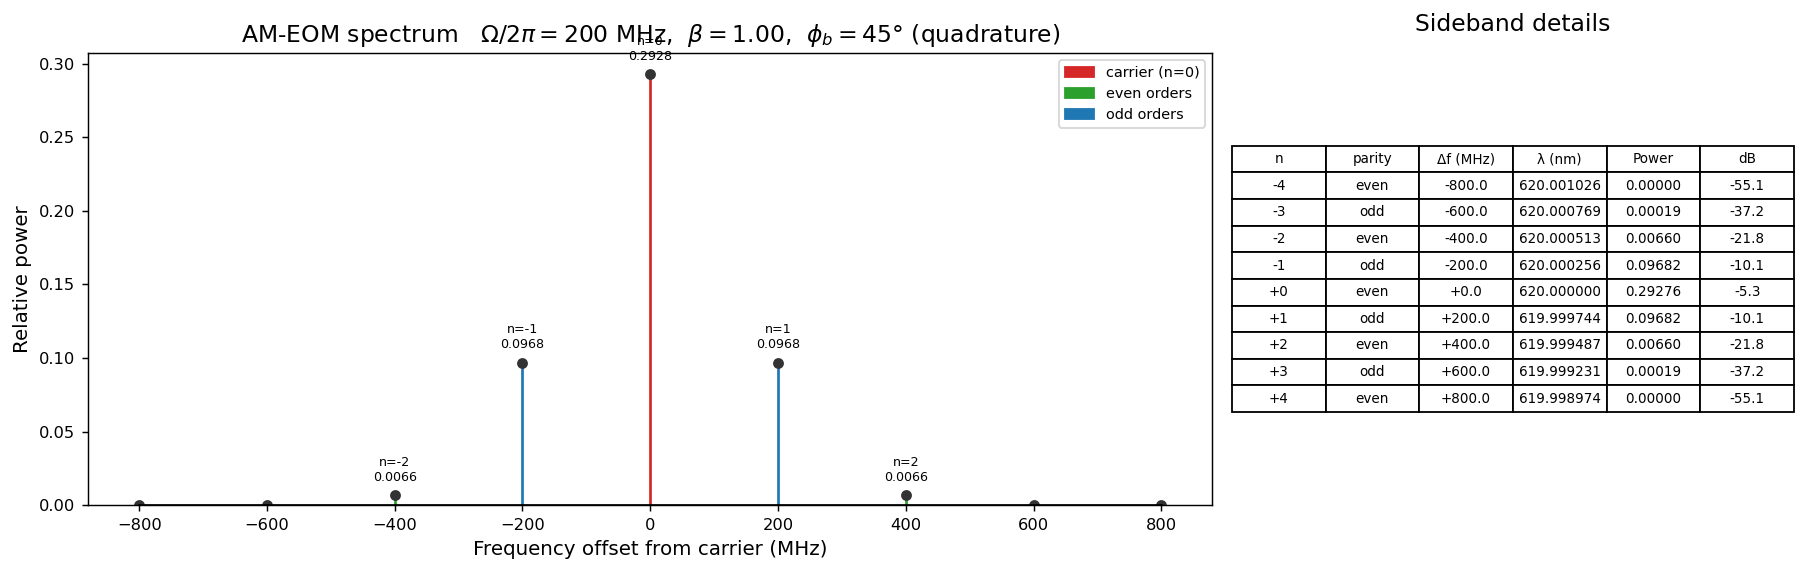

Visible sidebands: 9   (orders -4 … +4)
Total power in visible sidebands: 0.50000
  Even-order power: 0.30597
  Odd-order power : 0.19403


In [9]:
def am_sideband_power(n, beta, phi_b):
    """Power of the n-th sideband for a MZM amplitude EOM."""
    jn2 = besselJ(n, beta) ** 2
    if n % 2 == 0:
        return jn2 * np.cos(phi_b) ** 2
    else:
        return jn2 * np.sin(phi_b) ** 2


def plot_am_single_freq(Omega_MHz, beta, phi_b, n_max=10, power_floor_dB=-60):
    """
    Plot the AM-EOM optical spectrum for single-tone drive.

    Parameters
    ----------
    Omega_MHz : float – RF drive frequency (MHz)
    beta      : float – modulation index (rad)
    phi_b     : float – bias phase (rad),  0 = max-T,  π/4 = quadrature,  π/2 = null
    n_max     : int   – highest sideband order to include
    power_floor_dB : float – visibility threshold
    """
    orders = np.arange(-n_max, n_max + 1)
    powers = np.array([am_sideband_power(n, beta, phi_b) for n in orders])
    freqs_offset = orders * Omega_MHz

    mask = 10 * np.log10(np.maximum(powers, 1e-30)) >= power_floor_dB
    orders_s  = orders[mask]
    freqs_s   = freqs_offset[mask]
    powers_s  = powers[mask]

    bias_deg = np.degrees(phi_b)
    bias_label = ""
    if abs(phi_b) < 0.01:
        bias_label = " (max transmission)"
    elif abs(phi_b - np.pi/4) < 0.01:
        bias_label = " (quadrature)"
    elif abs(phi_b - np.pi/2) < 0.01:
        bias_label = " (null / carrier suppressed)"

    # ── Figure ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5),
                                    gridspec_kw={"width_ratios": [2, 1]})

    even_mask = orders_s % 2 == 0
    colors = ["#d62728" if n == 0 else ("#2ca02c" if n % 2 == 0 else "#1f77b4")
              for n in orders_s]

    ml, sl, bl = ax1.stem(freqs_s, powers_s, linefmt="-", markerfmt="o", basefmt="k-")
    ml.set_markersize(5)
    sl.set_colors(colors)
    ml.set_color("#333")

    ax1.set_xlabel("Frequency offset from carrier (MHz)")
    ax1.set_ylabel(r"Relative power")
    ax1.set_title(rf"AM-EOM spectrum   $\Omega/2\pi={Omega_MHz}$ MHz,  "
                  rf"$\beta={beta:.2f}$,  $\phi_b={bias_deg:.0f}°${bias_label}")
    ax1.set_ylim(bottom=0)
    ax1.axhline(0, color="k", lw=0.5)

    for n, f, p in zip(orders_s, freqs_s, powers_s):
        if p > 0.003:
            ax1.annotate(f"n={n}\n{p:.4f}", (f, p), textcoords="offset points",
                         xytext=(0, 8), ha="center", fontsize=7)

    from matplotlib.patches import Patch
    ax1.legend(handles=[
        Patch(color="#d62728", label="carrier (n=0)"),
        Patch(color="#2ca02c", label="even orders"),
        Patch(color="#1f77b4", label="odd orders"),
    ], fontsize=8, loc="upper right")

    # ── Table ──
    table_data = []
    for n, f, p in zip(orders_s, freqs_s, powers_s):
        wl_nm = c / (nu_carrier + f * 1e6) * 1e9
        parity = "even" if n % 2 == 0 else "odd"
        table_data.append([
            f"{n:+d}", parity,
            f"{f:+.1f}",
            f"{wl_nm:.6f}",
            f"{p:.5f}",
            f"{10*np.log10(max(p,1e-30)):+.1f}",
        ])
    col_labels = ["n", "parity", "Δf (MHz)", "λ (nm)", "Power", "dB"]
    ax2.axis("off")
    tbl = ax2.table(cellText=table_data, colLabels=col_labels,
                    loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7.5)
    tbl.scale(1.0, 1.2)
    ax2.set_title("Sideband details", pad=12)

    fig.tight_layout()
    plt.show()

    total = np.sum(powers_s)
    print(f"Visible sidebands: {len(orders_s)}   (orders {orders_s[0]:+d} … {orders_s[-1]:+d})")
    print(f"Total power in visible sidebands: {total:.5f}")
    print(f"  Even-order power: {np.sum(powers_s[orders_s % 2 == 0]):.5f}")
    print(f"  Odd-order power : {np.sum(powers_s[orders_s % 2 != 0]):.5f}")


# ── Quadrature bias, moderate modulation ──
plot_am_single_freq(Omega_MHz=200, beta=1.0, phi_b=np.pi/4)

## 2. Bias-point sweep

Three columns show the three canonical bias points. Two rows sweep from low to high modulation depth.

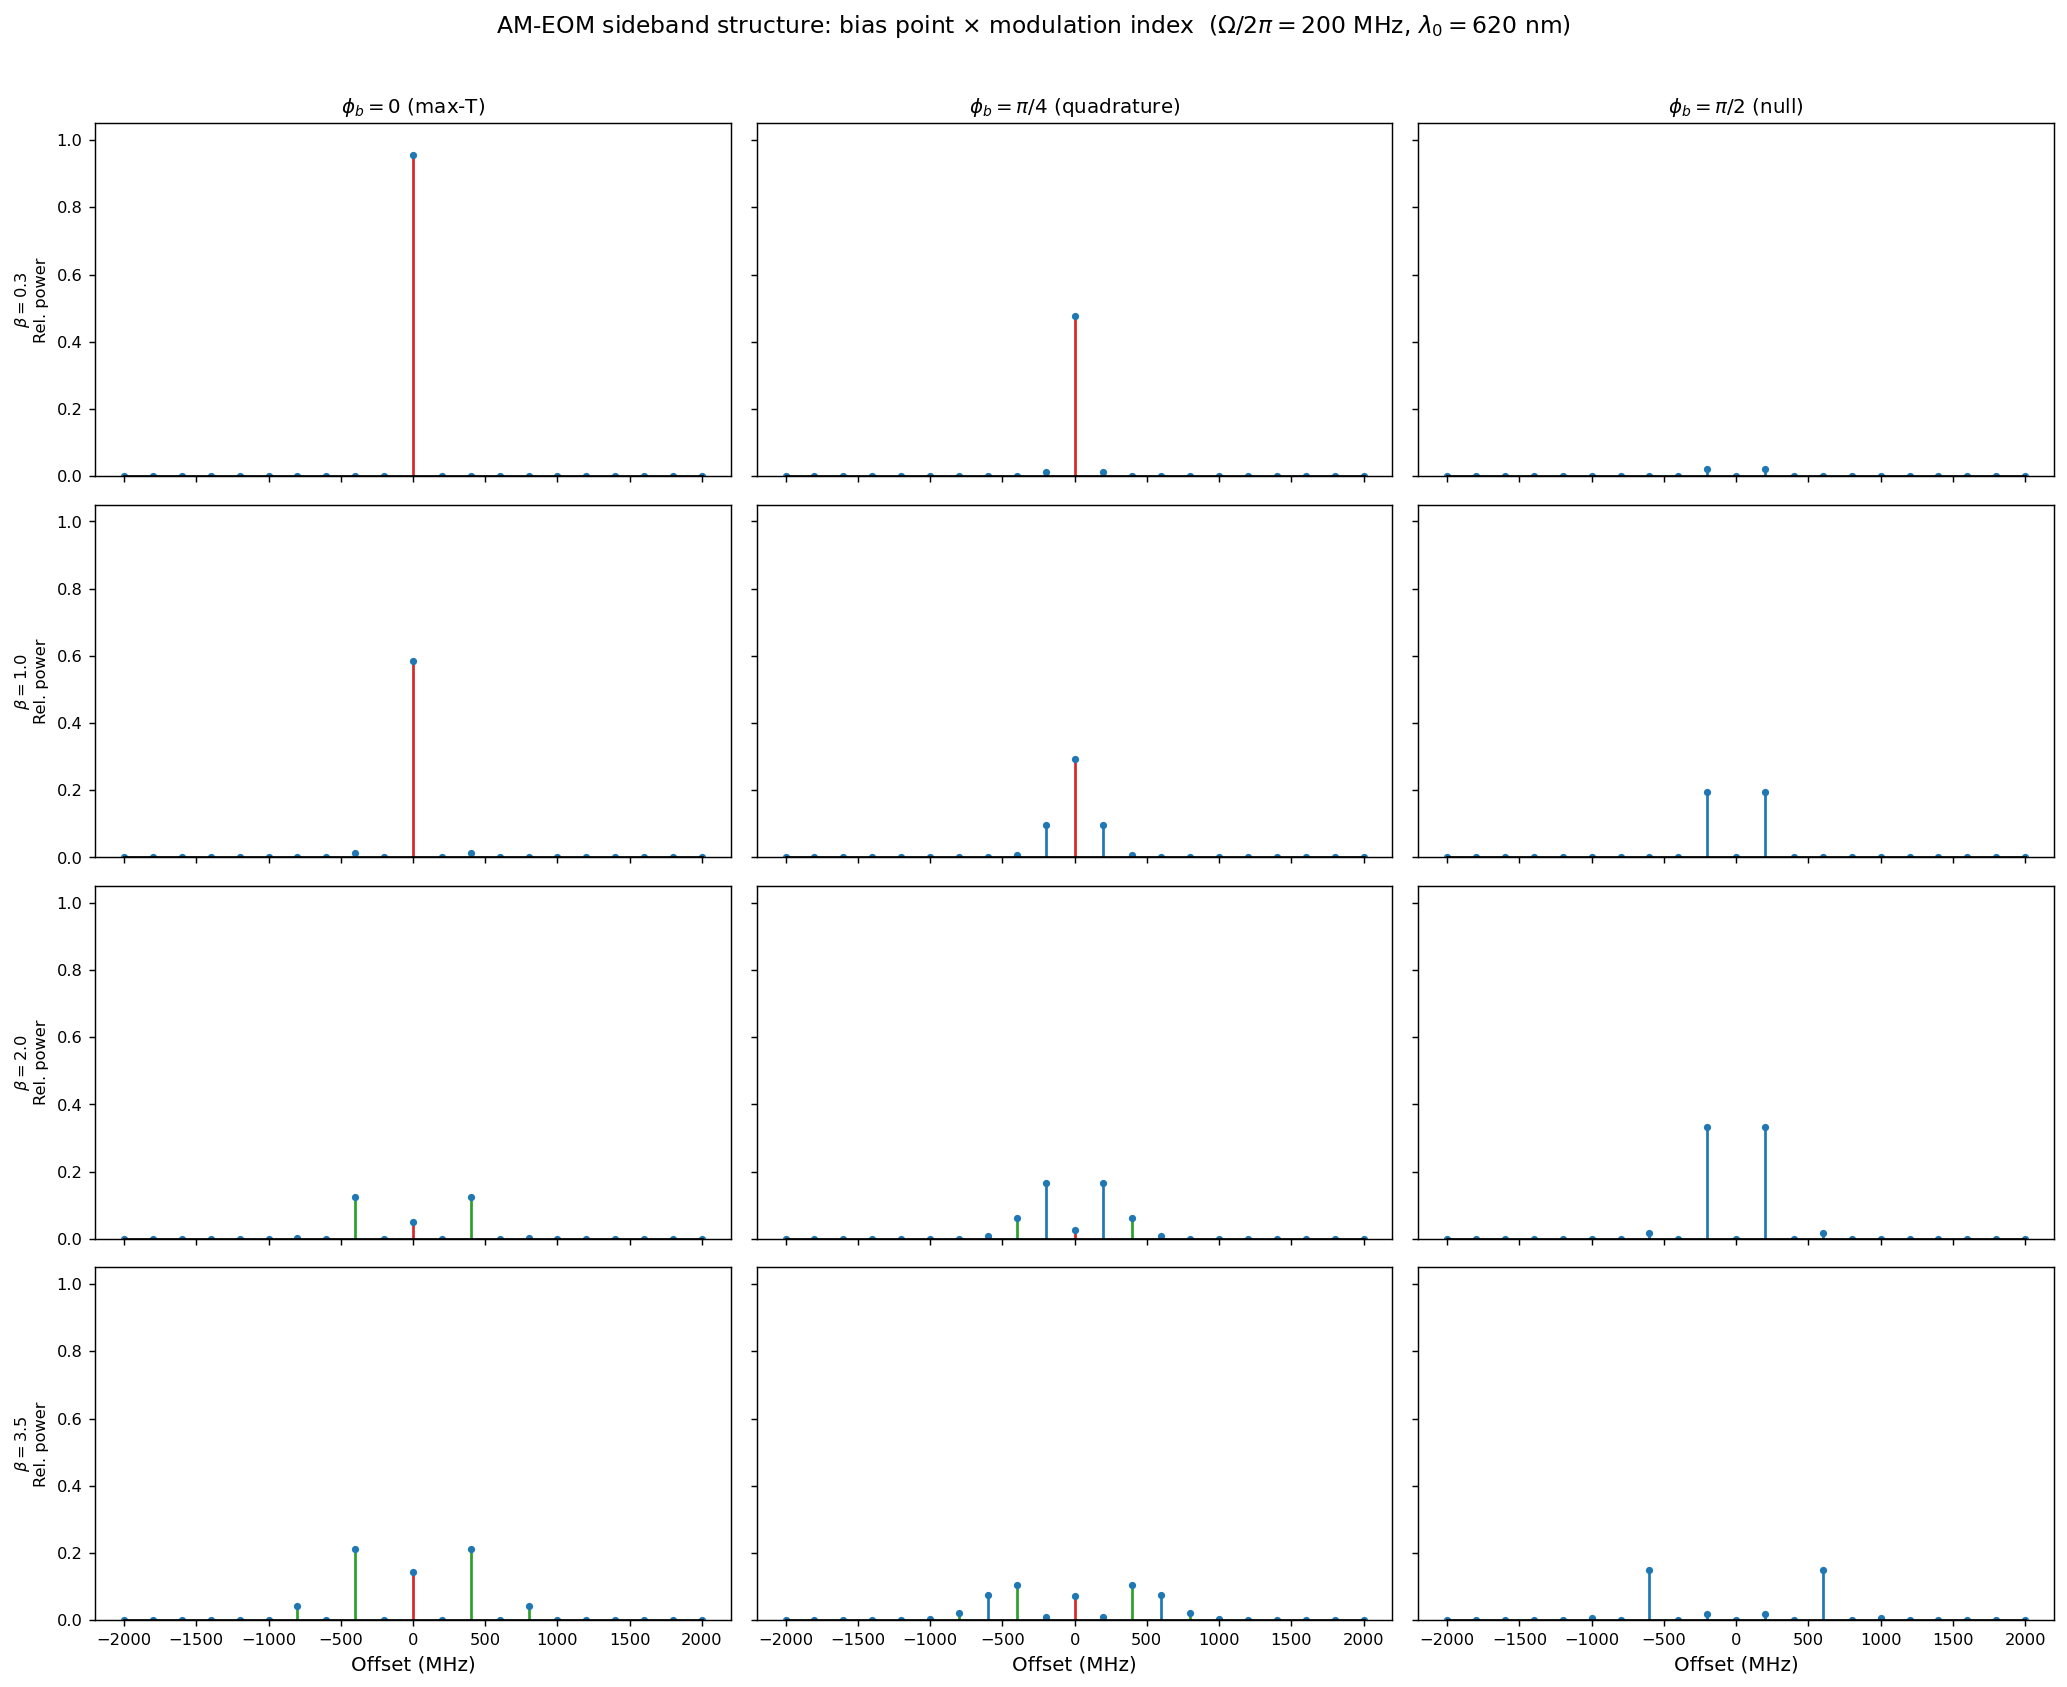

Red = carrier (n=0),  Green = even-order sidebands,  Blue = odd-order sidebands
At null bias (right column): carrier and all even orders vanish → carrier-suppressed modulation
At max-T bias (left column): all odd orders vanish


In [10]:
bias_points = [
    (0,        r"$\phi_b=0$ (max-T)"),
    (np.pi/4,  r"$\phi_b=\pi/4$ (quadrature)"),
    (np.pi/2,  r"$\phi_b=\pi/2$ (null)"),
]
betas = [0.3, 1.0, 2.0, 3.5]
Omega_MHz = 200
n_max = 10
orders = np.arange(-n_max, n_max + 1)
freqs = orders * Omega_MHz

fig, axes = plt.subplots(len(betas), len(bias_points),
                         figsize=(16, 3.2 * len(betas)),
                         sharex=True, sharey=True)

for col, (phi_b, phi_label) in enumerate(bias_points):
    for row, beta in enumerate(betas):
        ax = axes[row, col]
        powers = np.array([am_sideband_power(n, beta, phi_b) for n in orders])
        colors = ["#d62728" if n == 0 else ("#2ca02c" if n % 2 == 0 else "#1f77b4")
                  for n in orders]
        ml, sl, bl = ax.stem(freqs, powers, linefmt="-", markerfmt="o", basefmt="k-")
        ml.set_markersize(3)
        sl.set_colors(colors)
        ax.set_ylim(0, 1.05)
        ax.axhline(0, color="k", lw=0.3)
        if row == 0:
            ax.set_title(phi_label, fontsize=11)
        if col == 0:
            ax.set_ylabel(rf"$\beta={beta}$" + "\n" + r"Rel. power", fontsize=9)
        if row == len(betas) - 1:
            ax.set_xlabel("Offset (MHz)")

fig.suptitle(rf"AM-EOM sideband structure: bias point × modulation index  "
             rf"($\Omega/2\pi={Omega_MHz}$ MHz, $\lambda_0=620$ nm)",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

print("Red = carrier (n=0),  Green = even-order sidebands,  Blue = odd-order sidebands")
print("At null bias (right column): carrier and all even orders vanish → carrier-suppressed modulation")
print("At max-T bias (left column): all odd orders vanish")

## 3. Two-frequency AM-EOM modulation

Drive with $\Omega_1$ and $\Omega_2$ simultaneously. The parity rule now depends on $n+m$:
- $n+m$ **even** → power scales with $\cos^2\phi_b$
- $n+m$ **odd** → power scales with $\sin^2\phi_b$

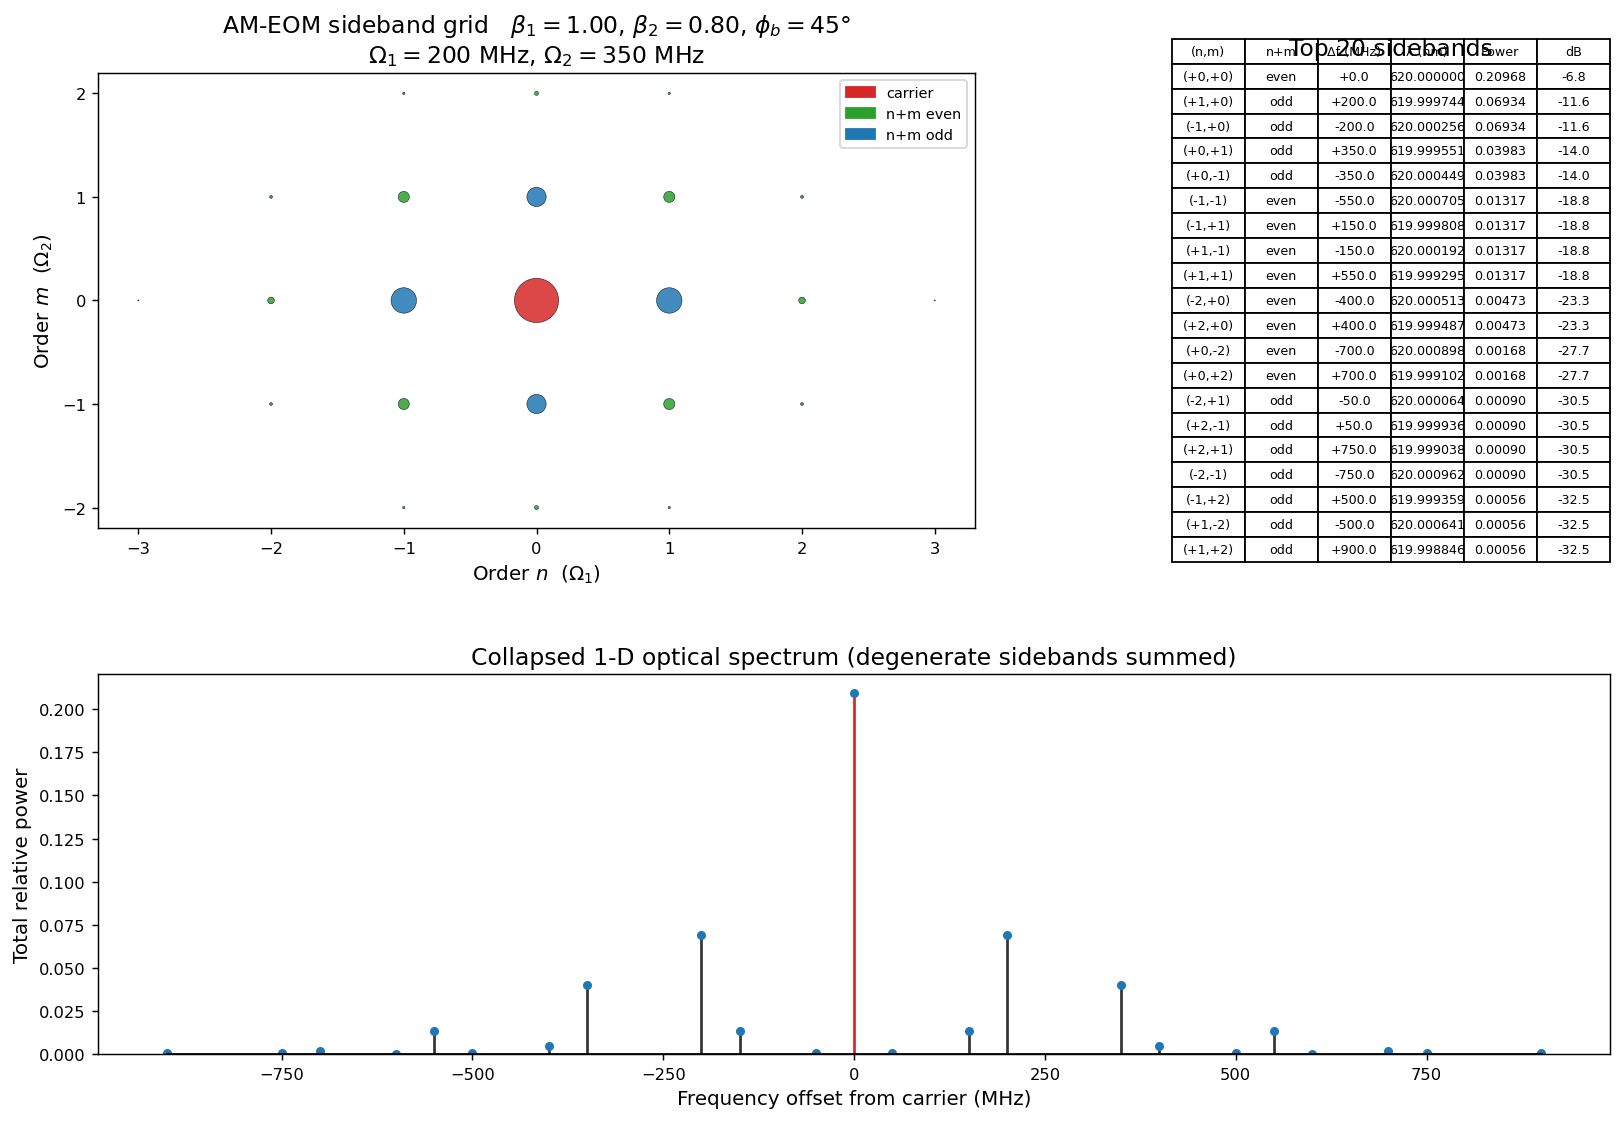

Visible (n,m) components: 23
Total power (all orders): 0.50000


In [11]:
def am_two_freq_power(n, m, beta1, beta2, phi_b):
    """Power of the (n, m) sideband for two-tone AM-EOM."""
    jn2 = besselJ(n, beta1) ** 2 * besselJ(m, beta2) ** 2
    if (n + m) % 2 == 0:
        return jn2 * np.cos(phi_b) ** 2
    else:
        return jn2 * np.sin(phi_b) ** 2


def plot_am_two_freq(Omega1_MHz, Omega2_MHz, beta1, beta2, phi_b,
                     n_max=6, power_floor_dB=-40):
    orders = np.arange(-n_max, n_max + 1)
    N = len(orders)

    ns, ms = np.meshgrid(orders, orders, indexing="ij")
    power_grid = np.zeros_like(ns, dtype=float)
    for i in range(N):
        for j in range(N):
            power_grid[i, j] = am_two_freq_power(orders[i], orders[j],
                                                  beta1, beta2, phi_b)
    freq_grid = ns * Omega1_MHz + ms * Omega2_MHz
    parity_grid = (ns + ms) % 2  # 0 = even, 1 = odd

    mask = 10 * np.log10(np.maximum(power_grid, 1e-30)) >= power_floor_dB
    ns_f = ns[mask];  ms_f = ms[mask]
    freqs_f = freq_grid[mask];  powers_f = power_grid[mask]
    parity_f = parity_grid[mask]

    bias_deg = np.degrees(phi_b)

    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1], width_ratios=[2, 1],
                          hspace=0.35, wspace=0.30)

    # ── 2D bubble chart ──
    ax_bub = fig.add_subplot(gs[0, 0])
    sizes = powers_f / max(powers_f.max(), 1e-30) * 600
    colors_bub = np.where(parity_f == 0, "#2ca02c", "#1f77b4")
    carrier_mask = (ns_f == 0) & (ms_f == 0)
    colors_bub[carrier_mask] = "#d62728"

    ax_bub.scatter(ns_f, ms_f, s=sizes, c=colors_bub,
                   edgecolors="k", linewidths=0.3, alpha=0.85)
    ax_bub.set_xlabel(rf"Order $n$  ($\Omega_1$)")
    ax_bub.set_ylabel(rf"Order $m$  ($\Omega_2$)")
    ax_bub.set_title(rf"AM-EOM sideband grid   $\beta_1={beta1:.2f}$, $\beta_2={beta2:.2f}$, "
                     rf"$\phi_b={bias_deg:.0f}°$"
                     f"\n" rf"$\Omega_1={Omega1_MHz}$ MHz, $\Omega_2={Omega2_MHz}$ MHz")
    ax_bub.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax_bub.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    from matplotlib.patches import Patch
    ax_bub.legend(handles=[
        Patch(color="#d62728", label="carrier"),
        Patch(color="#2ca02c", label="n+m even"),
        Patch(color="#1f77b4", label="n+m odd"),
    ], fontsize=8, loc="upper right")

    # ── Table of strongest sidebands ──
    ax_tbl = fig.add_subplot(gs[0, 1])
    ax_tbl.axis("off")
    sort_idx = np.argsort(-powers_f)[:20]
    table_data = []
    for idx in sort_idx:
        n, m, f, p = ns_f[idx], ms_f[idx], freqs_f[idx], powers_f[idx]
        par = "even" if (n + m) % 2 == 0 else "odd"
        wl_nm = c / (nu_carrier + f * 1e6) * 1e9
        table_data.append([
            f"({n:+d},{m:+d})", par,
            f"{f:+.1f}",
            f"{wl_nm:.6f}",
            f"{p:.5f}",
            f"{10*np.log10(max(p,1e-30)):+.1f}",
        ])
    col_labels = ["(n,m)", "n+m", "Δf (MHz)", "λ (nm)", "Power", "dB"]
    tbl = ax_tbl.table(cellText=table_data, colLabels=col_labels,
                       loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    tbl.scale(1.0, 1.15)
    ax_tbl.set_title("Top 20 sidebands", pad=10)

    # ── Collapsed 1-D spectrum ──
    ax_sp = fig.add_subplot(gs[1, :])
    unique_freqs = {}
    unique_parity = {}
    for i in range(len(freq_grid.ravel())):
        f = round(freq_grid.ravel()[i], 4)
        p = power_grid.ravel()[i]
        par = parity_grid.ravel()[i]
        unique_freqs[f] = unique_freqs.get(f, 0) + p
        if f not in unique_parity or p > 0:
            unique_parity[f] = par

    freqs_1d = np.array(sorted(unique_freqs.keys()))
    powers_1d = np.array([unique_freqs[f] for f in freqs_1d])
    mask_1d = 10 * np.log10(np.maximum(powers_1d, 1e-30)) >= power_floor_dB

    f_show = freqs_1d[mask_1d]
    p_show = powers_1d[mask_1d]
    colors_1d = ["#d62728" if abs(f) < 0.01 else "#333" for f in f_show]

    ml, sl, bl = ax_sp.stem(f_show, p_show, linefmt="-", markerfmt="o", basefmt="k-")
    ml.set_markersize(4)
    sl.set_colors(colors_1d)

    ax_sp.set_xlabel("Frequency offset from carrier (MHz)")
    ax_sp.set_ylabel("Total relative power")
    ax_sp.set_title("Collapsed 1-D optical spectrum (degenerate sidebands summed)")
    ax_sp.set_ylim(bottom=0)

    plt.show()

    print(f"Visible (n,m) components: {mask.sum()}")
    print(f"Total power (all orders): {power_grid.sum():.5f}")


# ── Quadrature bias ──
plot_am_two_freq(Omega1_MHz=200, Omega2_MHz=350,
                 beta1=1.0, beta2=0.8, phi_b=np.pi/4)

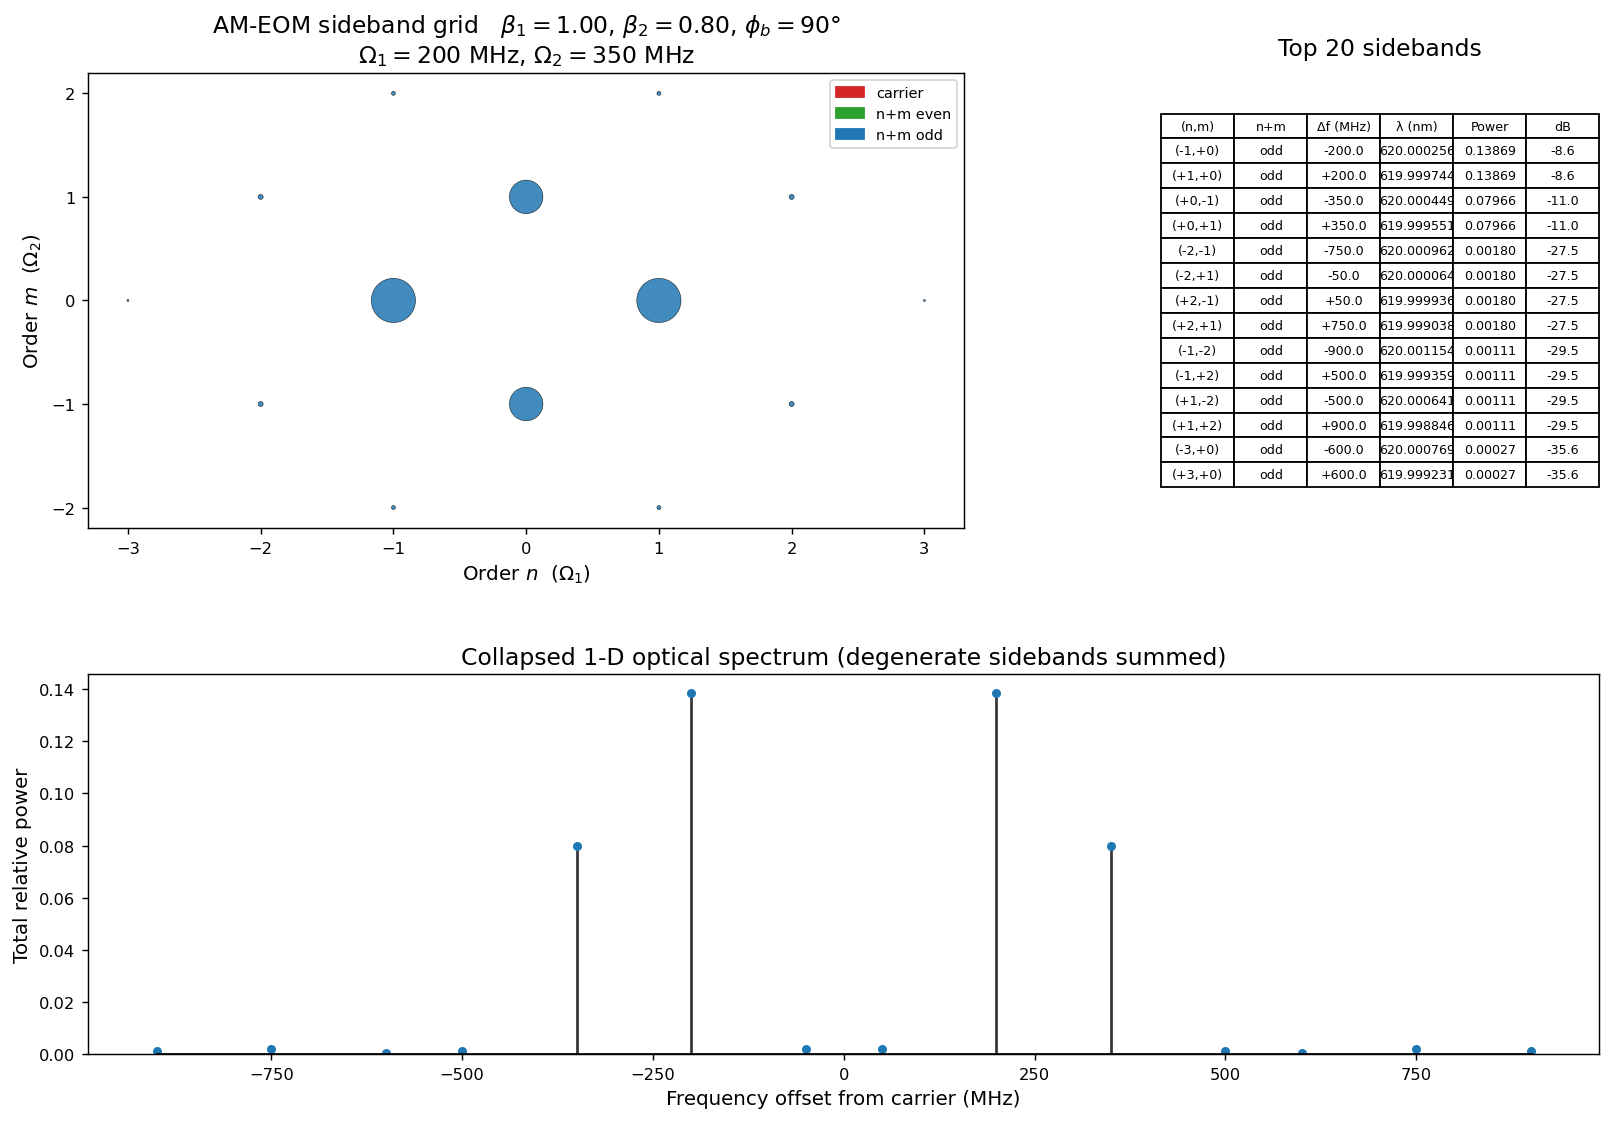

Visible (n,m) components: 14
Total power (all orders): 0.44902


In [12]:
# ── Same parameters but at null bias → carrier suppressed ──
plot_am_two_freq(Omega1_MHz=200, Omega2_MHz=350,
                 beta1=1.0, beta2=0.8, phi_b=np.pi/2)

## 4. Interactive explorers

Drag the sliders to see how the AM-EOM spectrum changes with modulation index, RF frequency, and — crucially — the **bias point**.

In [13]:
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

@interact(
    beta=FloatSlider(value=1.0, min=0.01, max=5.0, step=0.05,
                     description="β (rad)", continuous_update=False),
    Omega_MHz=FloatSlider(value=200, min=10, max=2000, step=10,
                          description="Ω/2π (MHz)", continuous_update=False),
    phi_b_choice=Dropdown(
        options=[("Max transmission (φ=0)", 0.0),
                 ("Quadrature (φ=π/4)", np.pi/4),
                 ("Null / carrier suppressed (φ=π/2)", np.pi/2),
                 ("Custom…", -1)],
        value=np.pi/4, description="Bias point"),
    phi_b_custom=FloatSlider(value=0.5, min=0.0, max=1.5708, step=0.01,
                             description="φ_b custom (rad)", continuous_update=False),
    n_max=IntSlider(value=10, min=3, max=20, description="n_max"),
)
def interactive_am_single(beta, Omega_MHz, phi_b_choice, phi_b_custom, n_max):
    phi_b = phi_b_custom if phi_b_choice == -1 else phi_b_choice
    plot_am_single_freq(Omega_MHz, beta, phi_b, n_max=n_max)

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='β (rad)', max=5.0, min=0.01…

In [14]:
@interact(
    beta1=FloatSlider(value=1.0, min=0.01, max=4.0, step=0.05,
                      description="β₁", continuous_update=False),
    beta2=FloatSlider(value=0.8, min=0.01, max=4.0, step=0.05,
                      description="β₂", continuous_update=False),
    Omega1_MHz=FloatSlider(value=200, min=10, max=2000, step=10,
                           description="Ω₁ (MHz)", continuous_update=False),
    Omega2_MHz=FloatSlider(value=350, min=10, max=2000, step=10,
                           description="Ω₂ (MHz)", continuous_update=False),
    phi_b_choice=Dropdown(
        options=[("Max transmission (φ=0)", 0.0),
                 ("Quadrature (φ=π/4)", np.pi/4),
                 ("Null / carrier suppressed (φ=π/2)", np.pi/2)],
        value=np.pi/4, description="Bias point"),
    n_max=IntSlider(value=6, min=2, max=12, description="n_max"),
)
def interactive_am_two_tone(beta1, beta2, Omega1_MHz, Omega2_MHz, phi_b_choice, n_max):
    plot_am_two_freq(Omega1_MHz, Omega2_MHz, beta1, beta2,
                     phi_b=phi_b_choice, n_max=n_max)

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='β₁', max=4.0, min=0.01, ste…

## 5. AM-EOM vs Phase-EOM — side-by-side comparison

Direct comparison at the same $\beta$ and $\Omega$ so you can see the structural difference.

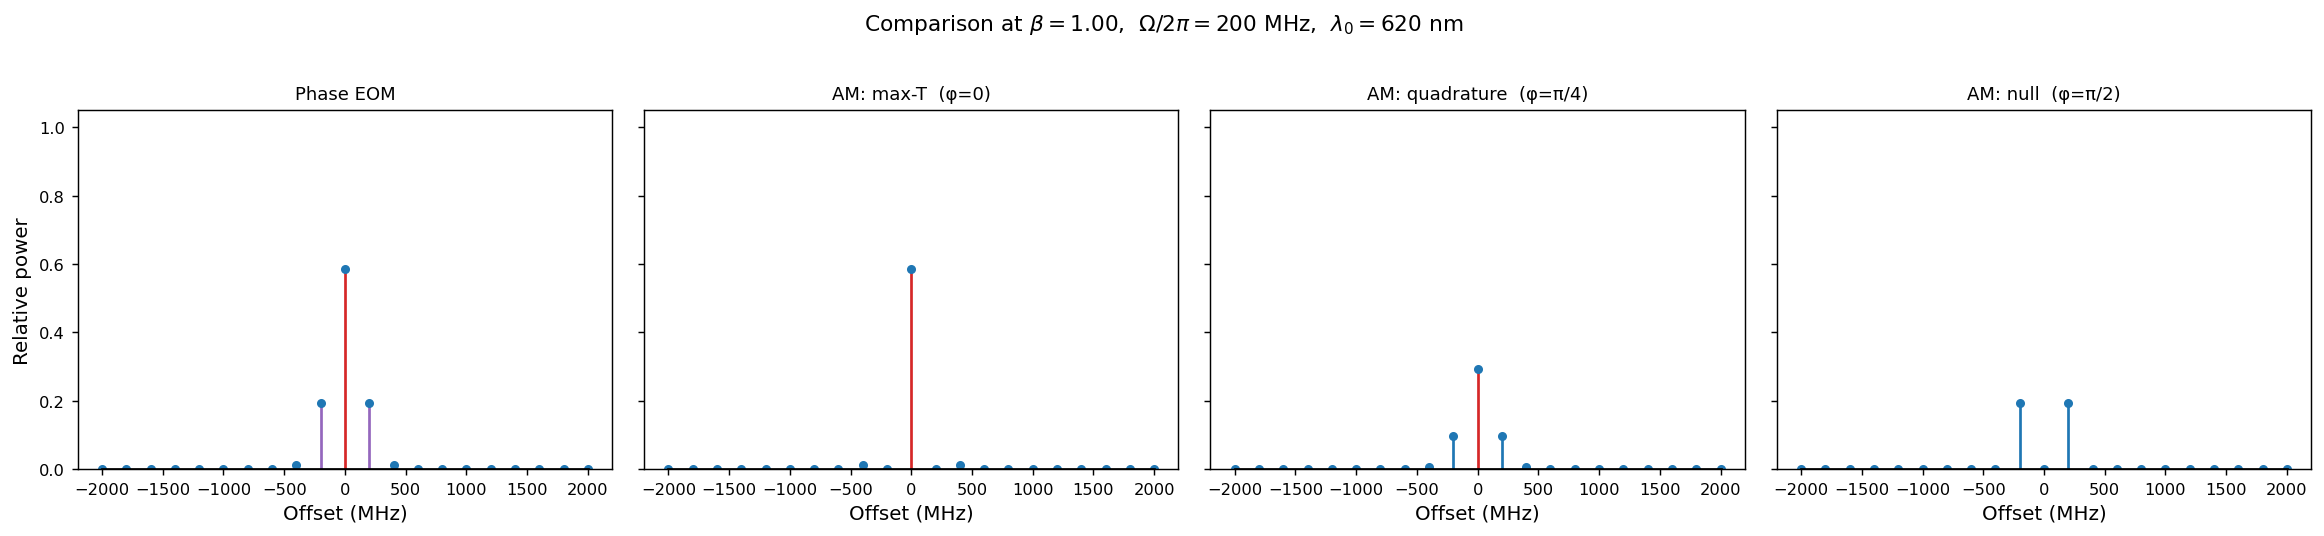

Key differences:
  • Phase EOM: all orders present, amplitudes depend ONLY on J_n(β)
  • AM-EOM (max-T): only even orders survive (odd killed by cos²(0)=1, sin²(0)=0)
  • AM-EOM (quadrature): all orders present but each halved (cos²=sin²=0.5)
  • AM-EOM (null): carrier suppressed! Only odd orders survive



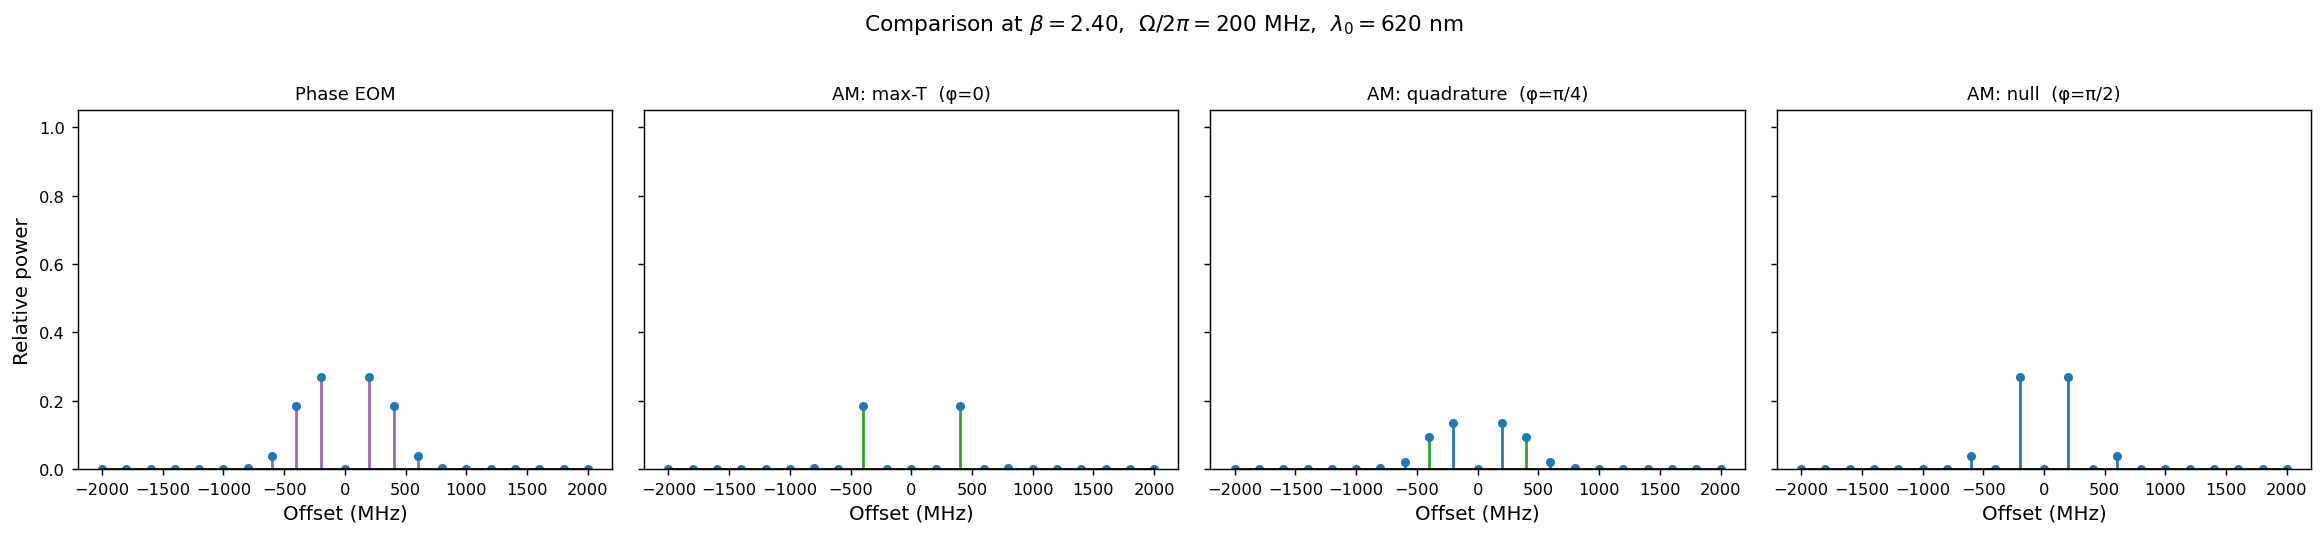

Key differences:
  • Phase EOM: all orders present, amplitudes depend ONLY on J_n(β)
  • AM-EOM (max-T): only even orders survive (odd killed by cos²(0)=1, sin²(0)=0)
  • AM-EOM (quadrature): all orders present but each halved (cos²=sin²=0.5)
  • AM-EOM (null): carrier suppressed! Only odd orders survive


In [15]:
def plot_am_vs_phase(Omega_MHz, beta, n_max=10):
    """Side-by-side: AM-EOM at three bias points vs phase-EOM."""
    orders = np.arange(-n_max, n_max + 1)
    freqs = orders * Omega_MHz

    # Phase EOM powers
    phase_powers = besselJ(orders, beta) ** 2

    bias_configs = [
        (0,        "AM: max-T  (φ=0)"),
        (np.pi/4,  "AM: quadrature  (φ=π/4)"),
        (np.pi/2,  "AM: null  (φ=π/2)"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

    # Phase EOM
    ax = axes[0]
    ml, sl, bl = ax.stem(freqs, phase_powers, linefmt="-", markerfmt="o", basefmt="k-")
    ml.set_markersize(4)
    sl.set_colors(["#d62728" if n == 0 else "#9467bd" for n in orders])
    ax.set_title(f"Phase EOM", fontsize=10)
    ax.set_xlabel("Offset (MHz)")
    ax.set_ylabel("Relative power")
    ax.set_ylim(0, 1.05)

    # AM EOM at different bias points
    for i, (phi_b, label) in enumerate(bias_configs):
        ax = axes[i + 1]
        am_powers = np.array([am_sideband_power(n, beta, phi_b) for n in orders])
        colors = ["#d62728" if n == 0 else ("#2ca02c" if n % 2 == 0 else "#1f77b4")
                  for n in orders]
        ml, sl, bl = ax.stem(freqs, am_powers, linefmt="-", markerfmt="o", basefmt="k-")
        ml.set_markersize(4)
        sl.set_colors(colors)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("Offset (MHz)")

    fig.suptitle(rf"Comparison at $\beta = {beta:.2f}$,  $\Omega/2\pi = {Omega_MHz}$ MHz,  $\lambda_0 = 620$ nm",
                 fontsize=12, y=1.02)
    fig.tight_layout()
    plt.show()

    print("Key differences:")
    print("  • Phase EOM: all orders present, amplitudes depend ONLY on J_n(β)")
    print("  • AM-EOM (max-T): only even orders survive (odd killed by cos²(0)=1, sin²(0)=0)")
    print("  • AM-EOM (quadrature): all orders present but each halved (cos²=sin²=0.5)")
    print("  • AM-EOM (null): carrier suppressed! Only odd orders survive")


plot_am_vs_phase(Omega_MHz=200, beta=1.0)
print()
plot_am_vs_phase(Omega_MHz=200, beta=2.4)

## 6. MZM transfer function

The cosine-squared intensity transfer curve and the operating points on it.

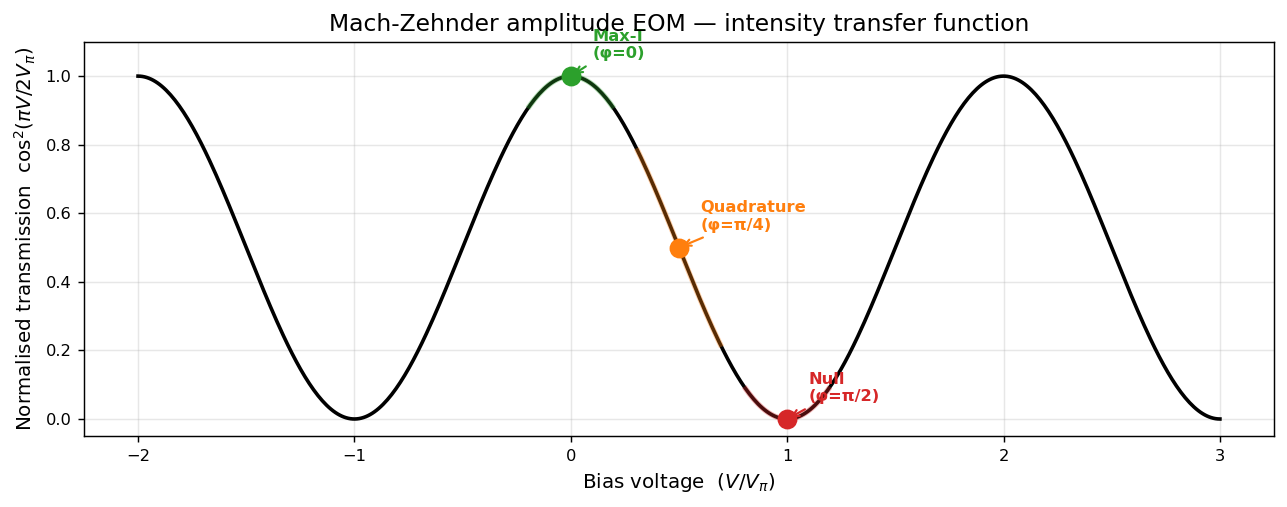

The shaded segments show the range swept by a small RF signal around each bias point.
At quadrature the transfer function is most linear → cleanest AM for small signals.
At null the carrier is suppressed and the output is dominated by sidebands.


In [16]:
V = np.linspace(-2, 3, 500)  # in units of V_pi
T = np.cos(np.pi * V / 2) ** 2

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(V, T, "k-", lw=2)
ax.set_xlabel(r"Bias voltage  ($V / V_\pi$)")
ax.set_ylabel(r"Normalised transmission  $\cos^2(\pi V / 2V_\pi)$")
ax.set_title("Mach-Zehnder amplitude EOM — intensity transfer function")
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

bias_pts = [
    (0,   "Max-T\n(φ=0)", "#2ca02c"),
    (0.5, "Quadrature\n(φ=π/4)", "#ff7f0e"),
    (1.0, "Null\n(φ=π/2)", "#d62728"),
]
for v_bias, label, col in bias_pts:
    t_val = np.cos(np.pi * v_bias / 2) ** 2
    ax.plot(v_bias, t_val, "o", ms=10, color=col, zorder=5)
    ax.annotate(label, (v_bias, t_val), textcoords="offset points",
                xytext=(12, 10), fontsize=9, color=col, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=col, lw=1.2))

    beta_demo = 0.3
    v_arr = np.linspace(v_bias - beta_demo * 2/np.pi, v_bias + beta_demo * 2/np.pi, 50)
    t_arr = np.cos(np.pi * v_arr / 2) ** 2
    ax.plot(v_arr, t_arr, "-", lw=3, color=col, alpha=0.35)

fig.tight_layout()
plt.show()

print("The shaded segments show the range swept by a small RF signal around each bias point.")
print("At quadrature the transfer function is most linear → cleanest AM for small signals.")
print("At null the carrier is suppressed and the output is dominated by sidebands.")

---

## 7. Practical example: $V_\pi = 2.5\,\text{V}$, null-bias carrier suppression

### Goal
Operate at the **null bias point** ($\phi_b = \pi/2$, $V_{\text{bias}} = V_\pi = 2.5\,\text{V}$) so the carrier and all even-order sidebands vanish. Then choose an RF amplitude that puts almost all power into the **first-order** ($n = \pm 1$) sidebands.

### Relationship between RF voltage and modulation index

$$\beta = \frac{\pi\, V_{\text{RF,peak}}}{2\, V_\pi} = \frac{\pi\, V_{\text{pp}}}{4\, V_\pi}$$

$$\Longrightarrow \quad V_{\text{pp}} = \frac{4\, V_\pi\, \beta}{\pi}$$

At null bias the surviving power in each order $n$ (odd only) is simply $J_n^2(\beta)$.
To keep the spectrum clean (dominant $\pm 1$ sidebands with negligible $\pm 3$ and higher), we want $\beta$ small enough that $J_3(\beta) \ll J_1(\beta)$.

In [18]:
V_pi = 2.5  # V

def beta_to_Vpp(beta, V_pi):
    """Convert modulation index to peak-to-peak RF voltage."""
    return 4 * V_pi * beta / np.pi

def Vpp_to_beta(Vpp, V_pi):
    """Convert peak-to-peak RF voltage to modulation index."""
    return np.pi * Vpp / (4 * V_pi)

# ── Survey: how sideband purity changes with β ──
print(f"V_π = {V_pi} V   (null bias: V_bias = V_π = {V_pi} V)")
print(f"{'β':>6s}  {'V_pp (V)':>9s}  {'J₁²(β)':>9s}  {'J₃²(β)':>10s}  {'J₃²/J₁² (dB)':>14s}  {'J₅²(β)':>10s}")
print("-" * 72)

for beta in [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.84]:
    Vpp = beta_to_Vpp(beta, V_pi)
    j1_sq = besselJ(1, beta) ** 2
    j3_sq = besselJ(3, beta) ** 2
    j5_sq = besselJ(5, beta) ** 2
    ratio_dB = 10 * np.log10(j3_sq / j1_sq) if j1_sq > 0 else -np.inf
    print(f"{beta:6.2f}  {Vpp:9.3f}  {j1_sq:9.5f}  {j3_sq:10.2e}  {ratio_dB:+14.1f}  {j5_sq:10.2e}")

print()
print("RECOMMENDED for clean ±1 sidebands:")
print("  β ≈ 0.5–1.0  →  V_pp ≈ 1.6–3.2 V")
print("  At β = 1.0:  third-order sidebands are ~27 dB below first-order.")
print(f"  β = 1.0  →  V_pp = {beta_to_Vpp(1.0, V_pi):.2f} V")
print()
print("For MAXIMUM first-order sideband power (at cost of ~13 dB third-order contamination):")
print(f"  β ≈ 1.84 (first maximum of J₁)  →  V_pp = {beta_to_Vpp(1.84, V_pi):.2f} V")

V_π = 2.5 V   (null bias: V_bias = V_π = 2.5 V)
     β   V_pp (V)     J₁²(β)      J₃²(β)    J₃²/J₁² (dB)      J₅²(β)
------------------------------------------------------------------------
  0.20      0.637    0.00990    2.76e-08           -55.5    6.92e-15
  0.40      1.273    0.03843    1.74e-06           -43.4    7.02e-12
  0.60      1.910    0.08220    1.94e-05           -36.3    3.98e-10
  0.80      2.546    0.13604    1.05e-04           -31.1    6.90e-09
  1.00      3.183    0.19364    3.83e-04           -27.0    6.24e-08
  1.20      3.820    0.24829    1.08e-03           -23.6    3.72e-07
  1.40      4.456    0.29371    2.55e-03           -20.6    1.66e-06
  1.84      5.857    0.33857    1.09e-02           -14.9    2.27e-05

RECOMMENDED for clean ±1 sidebands:
  β ≈ 0.5–1.0  →  V_pp ≈ 1.6–3.2 V
  At β = 1.0:  third-order sidebands are ~27 dB below first-order.
  β = 1.0  →  V_pp = 3.18 V

For MAXIMUM first-order sideband power (at cost of ~13 dB third-order contamination):
  β 

### 7a. Single-frequency: carrier-suppressed with clean ±1 sidebands

Three example RF amplitudes so you can see the trade-off between first-order sideband power and spectral purity.

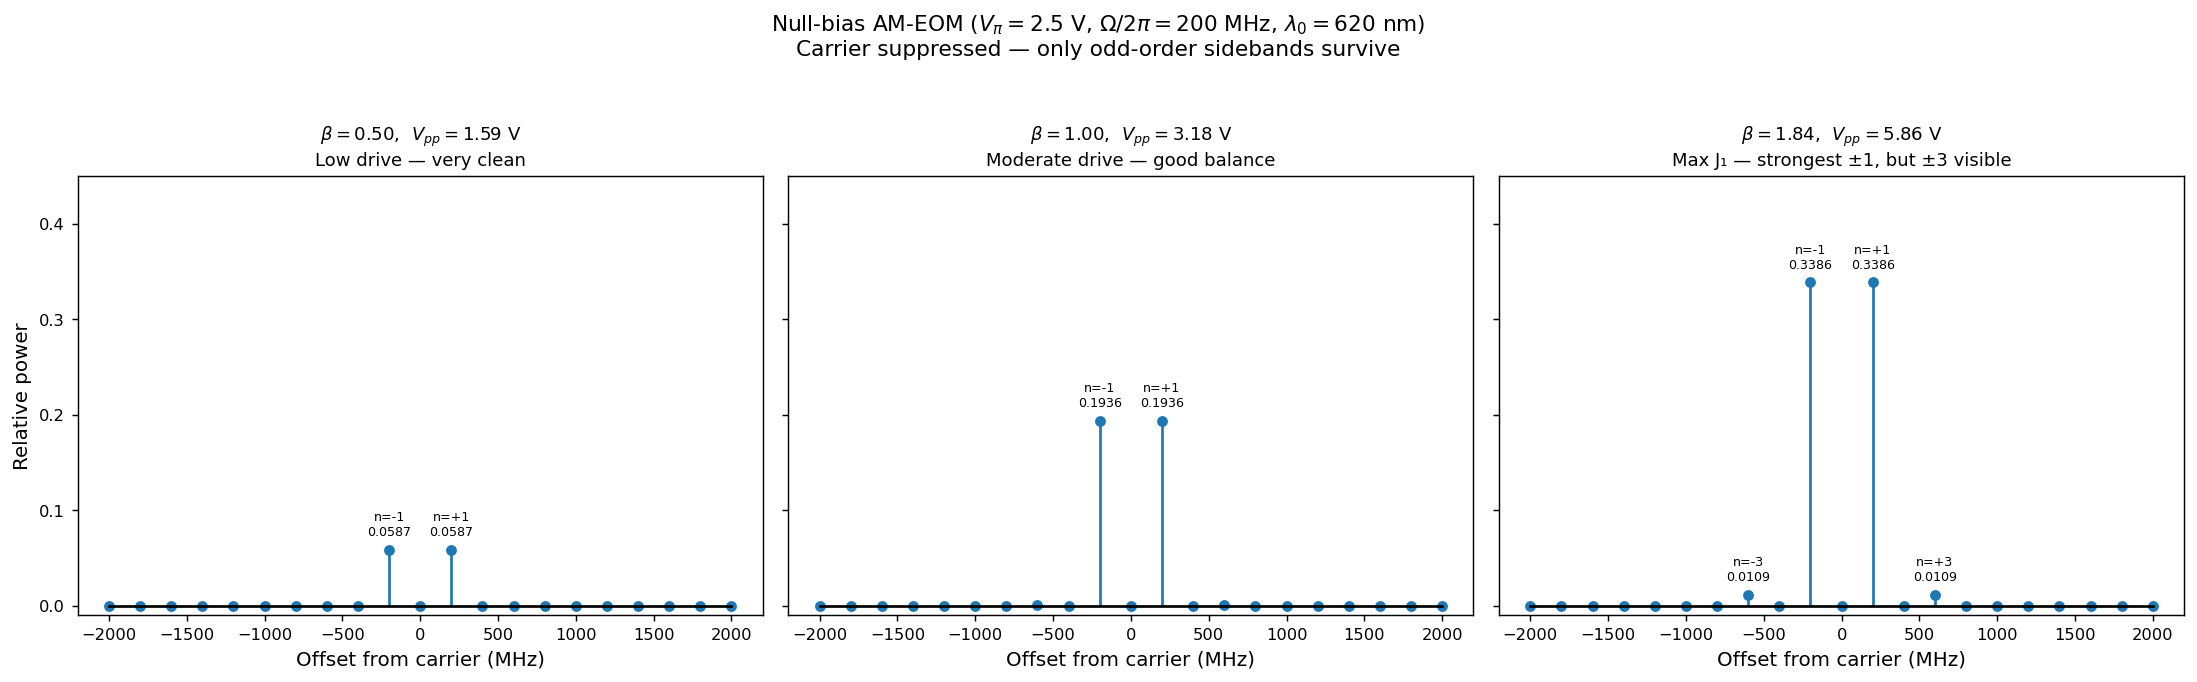

Summary (null bias, carrier suppressed):
  β=0.50  V_pp=1.59 V : ±1 power = 0.0587,  ±3 power = 6.57e-06  (-39.5 dB below ±1)
  β=1.00  V_pp=3.18 V : ±1 power = 0.1936,  ±3 power = 3.83e-04  (-27.0 dB below ±1)
  β=1.84  V_pp=5.86 V : ±1 power = 0.3386,  ±3 power = 1.09e-02  (-14.9 dB below ±1)

→ For your V_π = 2.5 V EOM at null bias,
  set V_pp ≈ 3.2 V for clean carrier-suppressed ±1 sidebands.


In [19]:
Omega_MHz = 200  # Example: 200 MHz RF drive
phi_b = np.pi / 2  # Null bias
n_max = 10
orders = np.arange(-n_max, n_max + 1)
freqs = orders * Omega_MHz

configs = [
    (0.5,  "Low drive — very clean"),
    (1.0,  "Moderate drive — good balance"),
    (1.84, "Max J₁ — strongest ±1, but ±3 visible"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (beta, desc) in zip(axes, configs):
    Vpp = beta_to_Vpp(beta, V_pi)
    powers = np.array([am_sideband_power(n, beta, phi_b) for n in orders])

    colors = ["#d62728" if n == 0 else ("#2ca02c" if n % 2 == 0 else "#1f77b4")
              for n in orders]
    ml, sl, bl = ax.stem(freqs, powers, linefmt="-", markerfmt="o", basefmt="k-")
    ml.set_markersize(5)
    sl.set_colors(colors)

    ax.set_title(rf"$\beta = {beta:.2f}$,  $V_{{pp}} = {Vpp:.2f}$ V" + f"\n{desc}",
                 fontsize=10)
    ax.set_xlabel("Offset from carrier (MHz)")
    ax.set_ylim(-0.01, 0.45)

    for n, f, p in zip(orders, freqs, powers):
        if p > 0.002:
            label = f"n={n:+d}\n{p:.4f}"
            ax.annotate(label, (f, p), textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=7)

axes[0].set_ylabel("Relative power")
fig.suptitle(rf"Null-bias AM-EOM ($V_\pi = {V_pi}$ V, $\Omega/2\pi = {Omega_MHz}$ MHz, $\lambda_0 = 620$ nm)"
             "\nCarrier suppressed — only odd-order sidebands survive",
             fontsize=12, y=1.04)
fig.tight_layout()
plt.show()

print("Summary (null bias, carrier suppressed):")
for beta, desc in configs:
    Vpp = beta_to_Vpp(beta, V_pi)
    j1 = besselJ(1, beta) ** 2
    j3 = besselJ(3, beta) ** 2
    ratio = 10 * np.log10(j3 / j1) if j1 > 0 else -np.inf
    print(f"  β={beta:.2f}  V_pp={Vpp:.2f} V : "
          f"±1 power = {j1:.4f},  ±3 power = {j3:.2e}  ({ratio:+.1f} dB below ±1)")
print()
print(f"→ For your V_π = {V_pi} V EOM at null bias,")
print(f"  set V_pp ≈ {beta_to_Vpp(1.0, V_pi):.1f} V for clean carrier-suppressed ±1 sidebands.")

### 7b. Two-frequency drive: two pairs of ±1 sidebands, carrier suppressed

Now drive the EOM with **two RF tones** $\Omega_1$ and $\Omega_2$ simultaneously. At null bias, the surviving sidebands have $n + m$ **odd**. 

For the cleanest result (only the four first-order sidebands at $\pm\Omega_1$ and $\pm\Omega_2$), we want:
- $(n, m) = (\pm 1, 0)$ → sidebands at $\pm\Omega_1$   (power $= J_1^2(\beta_1) \cdot J_0^2(\beta_2) \cdot \sin^2\phi_b$)
- $(n, m) = (0, \pm 1)$ → sidebands at $\pm\Omega_2$   (power $= J_0^2(\beta_1) \cdot J_1^2(\beta_2) \cdot \sin^2\phi_b$)

**But at null bias** $J_0^2 \cdot \cos^2(\pi/2) = 0$, so the $(0,0)$ carrier vanishes. The $(±1, 0)$ and $(0, ±1)$ terms have $n+m$ odd, so they survive with $\sin^2(\pi/2) = 1$.

**Watch out for cross-terms** like $(\pm 1, \pm 2)$ etc. — keep $\beta_1, \beta_2$ small to suppress them.

In [20]:
Omega1_MHz = 200   # First RF tone
Omega2_MHz = 350   # Second RF tone
phi_b = np.pi / 2  # Null bias

beta1_val = 0.8
beta2_val = 0.8
Vpp1 = beta_to_Vpp(beta1_val, V_pi)
Vpp2 = beta_to_Vpp(beta2_val, V_pi)

print(f"V_π = {V_pi} V,  null bias (V_bias = {V_pi} V)")
print(f"RF tone 1: Ω₁/2π = {Omega1_MHz} MHz,  β₁ = {beta1_val},  V_pp1 = {Vpp1:.2f} V")
print(f"RF tone 2: Ω₂/2π = {Omega2_MHz} MHz,  β₂ = {beta2_val},  V_pp2 = {Vpp2:.2f} V")
print()

# Compute all sidebands
n_max = 6
orders = np.arange(-n_max, n_max + 1)

sideband_list = []
for n in orders:
    for m in orders:
        p = am_two_freq_power(n, m, beta1_val, beta2_val, phi_b)
        f_offset = n * Omega1_MHz + m * Omega2_MHz
        if p > 1e-12:
            sideband_list.append((n, m, f_offset, p))

sideband_list.sort(key=lambda x: -x[3])

print(f"{'(n, m)':>10s}  {'Δf (MHz)':>10s}  {'λ (nm)':>14s}  {'Power':>10s}  {'dB':>8s}  Note")
print("-" * 75)
for n, m, f, p in sideband_list[:20]:
    wl = c / (nu_carrier + f * 1e6) * 1e9
    db = 10 * np.log10(p) if p > 0 else -np.inf
    note = ""
    if n == 0 and m == 0:
        note = "CARRIER (suppressed)"
    elif abs(n) + abs(m) == 1:
        note = "← DESIRED first-order"
    elif abs(n) <= 1 and abs(m) <= 1 and abs(n) + abs(m) == 2:
        note = "cross-term"
    print(f"({n:+d},{m:+d})".rjust(10) +
          f"  {f:+10.1f}  {wl:14.6f}  {p:10.6f}  {db:+8.1f}  {note}")

# ── Power budget ──
desired = sum(p for n, m, _, p in sideband_list if abs(n) + abs(m) == 1)
total = sum(p for _, _, _, p in sideband_list)
print(f"\nPower in desired ±1 sidebands: {desired:.4f}  ({desired/total*100:.1f}% of total)")
print(f"Total power in all sidebands : {total:.4f}")

V_π = 2.5 V,  null bias (V_bias = 2.5 V)
RF tone 1: Ω₁/2π = 200 MHz,  β₁ = 0.8,  V_pp1 = 2.55 V
RF tone 2: Ω₂/2π = 350 MHz,  β₂ = 0.8,  V_pp2 = 2.55 V

    (n, m)    Δf (MHz)          λ (nm)       Power        dB  Note
---------------------------------------------------------------------------
   (-1,+0)      -200.0      620.000256    0.097435     -10.1  ← DESIRED first-order
   (+0,-1)      -350.0      620.000449    0.097435     -10.1  ← DESIRED first-order
   (+0,+1)      +350.0      619.999551    0.097435     -10.1  ← DESIRED first-order
   (+1,+0)      +200.0      619.999744    0.097435     -10.1  ← DESIRED first-order
   (-2,-1)      -750.0      620.000962    0.000782     -31.1  
   (-2,+1)       -50.0      620.000064    0.000782     -31.1  
   (-1,-2)      -900.0      620.001154    0.000782     -31.1  
   (-1,+2)      +500.0      619.999359    0.000782     -31.1  
   (+1,-2)      -500.0      620.000641    0.000782     -31.1  
   (+1,+2)      +900.0      619.998846    0.000782    

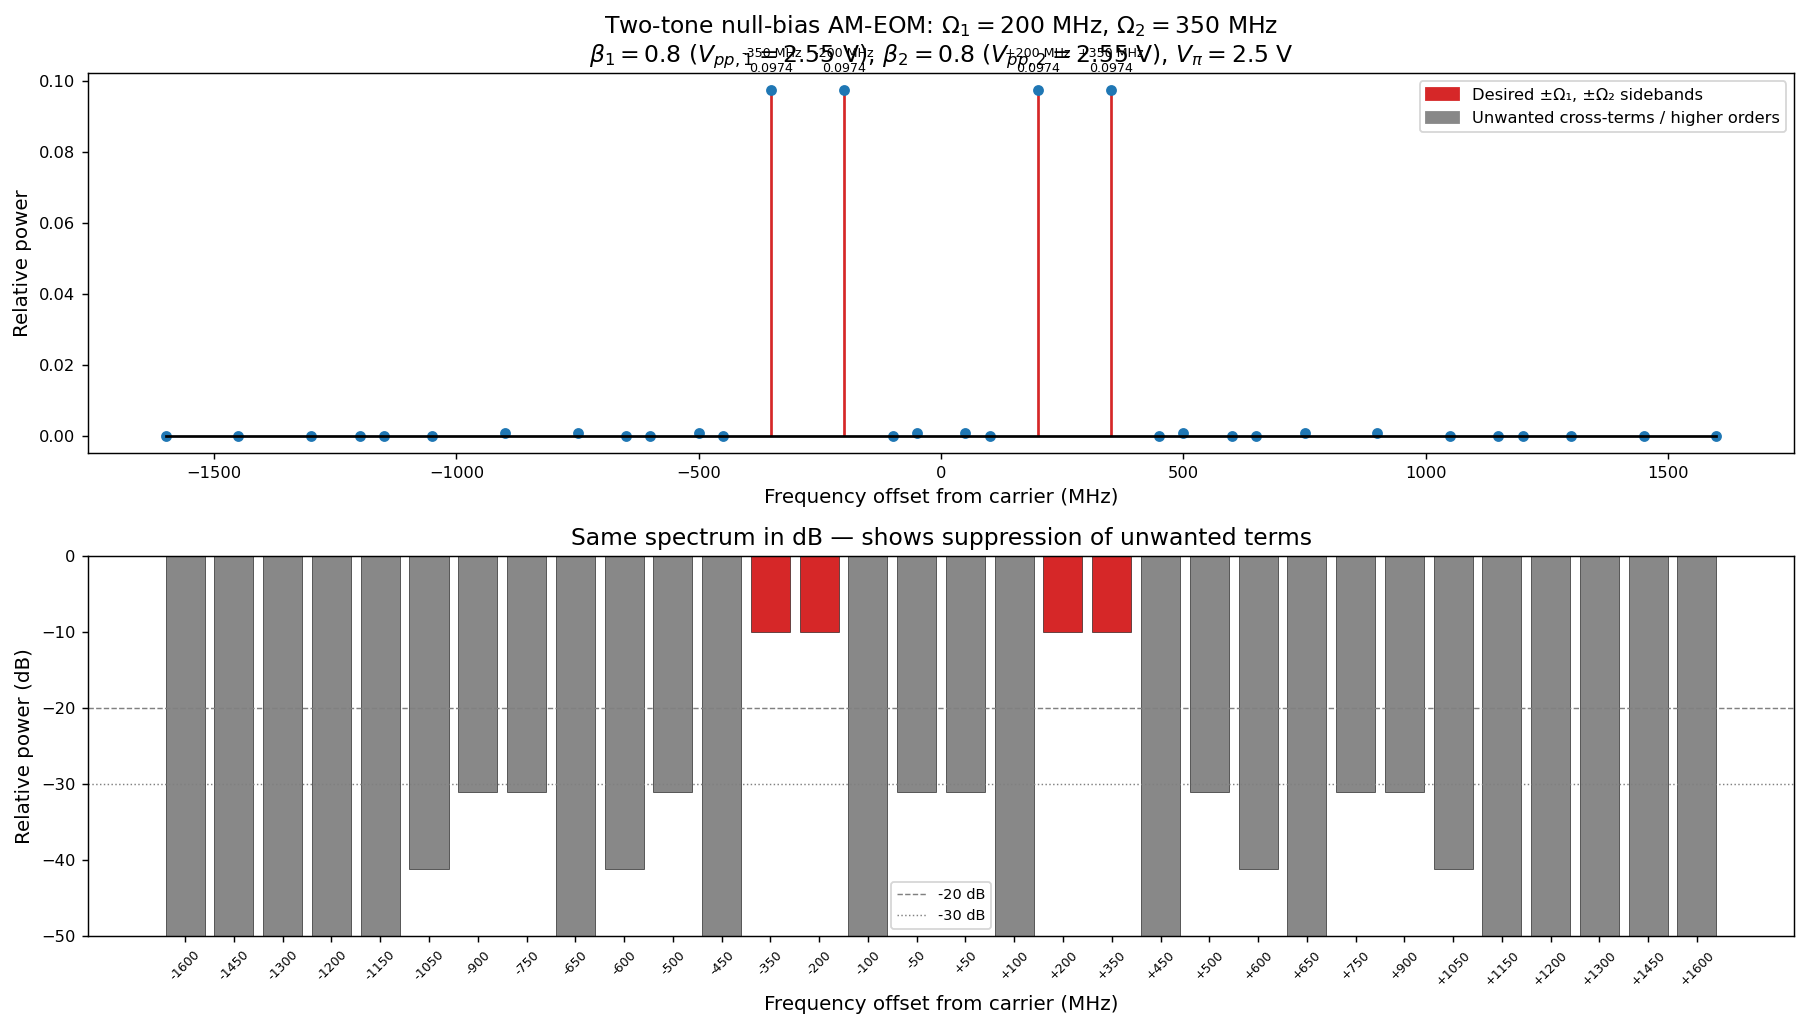

In [21]:
# ── Visualise the two-tone null-bias spectrum ──
fig, (ax_spec, ax_zoom) = plt.subplots(2, 1, figsize=(14, 8))

# Collect collapsed 1-D spectrum
freq_power_map = {}
for n, m, f, p in sideband_list:
    key = round(f, 2)
    freq_power_map[key] = freq_power_map.get(key, 0) + p

f_arr = np.array(sorted(freq_power_map.keys()))
p_arr = np.array([freq_power_map[f] for f in f_arr])
mask = p_arr > 1e-8

f_show = f_arr[mask]
p_show = p_arr[mask]

# Color: red for ±Ω1 and ±Ω2 (desired), grey for others
desired_freqs = {Omega1_MHz, -Omega1_MHz, Omega2_MHz, -Omega2_MHz}
colors = ["#d62728" if round(abs(f)) in {Omega1_MHz, Omega2_MHz} else "#888888"
          for f in f_show]

# Full spectrum
ml, sl, bl = ax_spec.stem(f_show, p_show, linefmt="-", markerfmt="o", basefmt="k-")
ml.set_markersize(5)
sl.set_colors(colors)
ax_spec.set_ylabel("Relative power")
ax_spec.set_title(rf"Two-tone null-bias AM-EOM: $\Omega_1 = {Omega1_MHz}$ MHz, $\Omega_2 = {Omega2_MHz}$ MHz"
                  f"\n" rf"$\beta_1 = {beta1_val}$ ($V_{{pp,1}} = {Vpp1:.2f}$ V), "
                  rf"$\beta_2 = {beta2_val}$ ($V_{{pp,2}} = {Vpp2:.2f}$ V), "
                  rf"$V_\pi = {V_pi}$ V")
ax_spec.set_xlabel("Frequency offset from carrier (MHz)")

for f, p in zip(f_show, p_show):
    if p > 0.005:
        ax_spec.annotate(f"{f:+.0f} MHz\n{p:.4f}",
                        (f, p), textcoords="offset points",
                        xytext=(0, 10), ha="center", fontsize=7)

from matplotlib.patches import Patch
ax_spec.legend(handles=[
    Patch(color="#d62728", label=r"Desired ±Ω₁, ±Ω₂ sidebands"),
    Patch(color="#888888", label="Unwanted cross-terms / higher orders"),
], fontsize=9)

# Zoomed: dB scale
p_dB = 10 * np.log10(np.maximum(p_show, 1e-30))
colors_db = colors.copy()
bars = ax_zoom.bar(range(len(f_show)), p_dB, color=colors_db, edgecolor="k", linewidth=0.3)
ax_zoom.set_xticks(range(len(f_show)))
ax_zoom.set_xticklabels([f"{f:+.0f}" for f in f_show], rotation=45, fontsize=7)
ax_zoom.set_ylabel("Relative power (dB)")
ax_zoom.set_xlabel("Frequency offset from carrier (MHz)")
ax_zoom.set_title("Same spectrum in dB — shows suppression of unwanted terms")
ax_zoom.axhline(-20, color="gray", ls="--", lw=0.8, label="-20 dB")
ax_zoom.axhline(-30, color="gray", ls=":", lw=0.8, label="-30 dB")
ax_zoom.legend(fontsize=8)
ax_zoom.set_ylim(bottom=-50)

fig.tight_layout()
plt.show()

### 7c. Choosing the right $\beta$ for two-tone operation

With two RF tones, the cross-terms $(\pm 1, \pm 2)$, $(\pm 3, 0)$, etc. become relevant. Below we sweep $\beta$ (same for both tones) to find the sweet spot.

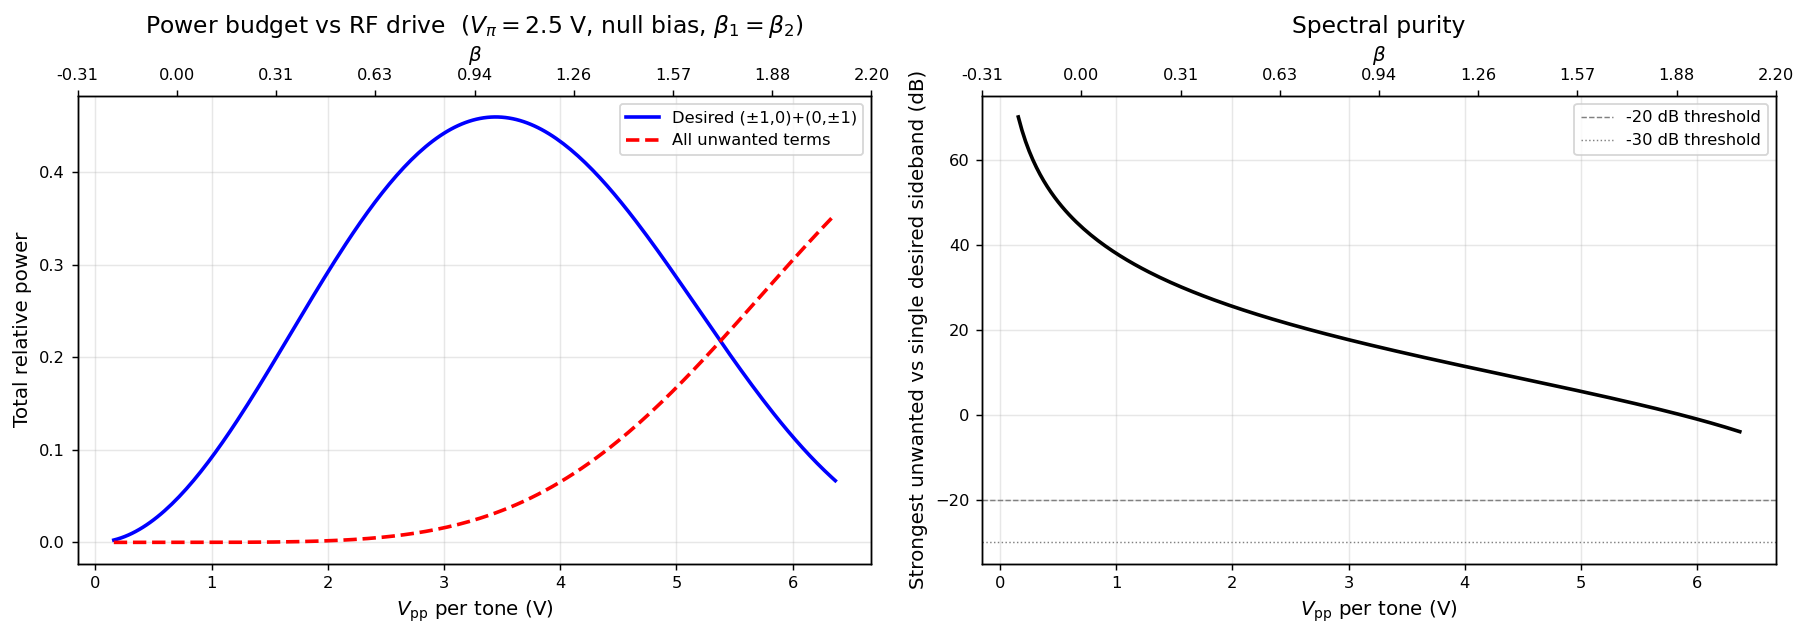

For unwanted terms < -20 dB below each desired sideband:
  β < 2.00  →  V_pp < 6.37 V per tone
  Desired sideband power (all 4): 0.0667

For unwanted terms < -30 dB below each desired sideband:
  β < 2.00  →  V_pp < 6.37 V per tone
  Desired sideband power (all 4): 0.0667



In [22]:
beta_sweep = np.linspace(0.05, 2.0, 200)
phi_b = np.pi / 2

desired_power = []    # sum of (±1,0) and (0,±1)
unwanted_power = []   # everything else
purity_dB = []        # ratio desired / strongest-unwanted

n_max_sweep = 8
orders_sweep = np.arange(-n_max_sweep, n_max_sweep + 1)

for beta in beta_sweep:
    desired = 0
    worst_unwanted = 0
    total_unwanted = 0

    for n in orders_sweep:
        for m in orders_sweep:
            p = am_two_freq_power(n, m, beta, beta, phi_b)
            if abs(n) + abs(m) == 1 and (n == 0 or m == 0):
                desired += p
            elif p > 1e-30:
                total_unwanted += p
                if p > worst_unwanted:
                    worst_unwanted = p

    desired_power.append(desired)
    unwanted_power.append(total_unwanted)
    if worst_unwanted > 0 and desired > 0:
        purity_dB.append(10 * np.log10(desired / 4 / worst_unwanted))
    else:
        purity_dB.append(np.nan)

desired_power = np.array(desired_power)
unwanted_power = np.array(unwanted_power)
purity_dB = np.array(purity_dB)
Vpp_sweep = beta_to_Vpp(beta_sweep, V_pi)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(Vpp_sweep, desired_power, "b-", lw=2, label="Desired (±1,0)+(0,±1)")
ax1.plot(Vpp_sweep, unwanted_power, "r--", lw=2, label="All unwanted terms")
ax1.set_xlabel(r"$V_{\rm pp}$ per tone (V)")
ax1.set_ylabel("Total relative power")
ax1.set_title(rf"Power budget vs RF drive  ($V_\pi = {V_pi}$ V, null bias, $\beta_1 = \beta_2$)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1b = ax1.twiny()
ax1b.set_xlim(ax1.get_xlim())
ax1b_ticks_V = ax1.get_xticks()
ax1b.set_xticks(ax1b_ticks_V)
ax1b.set_xticklabels([f"{Vpp_to_beta(v, V_pi):.2f}" for v in ax1b_ticks_V])
ax1b.set_xlabel(r"$\beta$")

ax2.plot(Vpp_sweep, purity_dB, "k-", lw=2)
ax2.axhline(-20, color="gray", ls="--", lw=0.8, label="-20 dB threshold")
ax2.axhline(-30, color="gray", ls=":", lw=0.8, label="-30 dB threshold")
ax2.set_xlabel(r"$V_{\rm pp}$ per tone (V)")
ax2.set_ylabel("Strongest unwanted vs single desired sideband (dB)")
ax2.set_title("Spectral purity")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2b = ax2.twiny()
ax2b.set_xlim(ax2.get_xlim())
ax2b_ticks_V = ax2.get_xticks()
ax2b.set_xticks(ax2b_ticks_V)
ax2b.set_xticklabels([f"{Vpp_to_beta(v, V_pi):.2f}" for v in ax2b_ticks_V])
ax2b.set_xlabel(r"$\beta$")

fig.tight_layout()
plt.show()

# Print recommendations
for target_dB in [-20, -30]:
    idx = np.argmin(np.abs(purity_dB - target_dB))
    if idx > 0:
        print(f"For unwanted terms < {target_dB} dB below each desired sideband:")
        print(f"  β < {beta_sweep[idx]:.2f}  →  V_pp < {Vpp_sweep[idx]:.2f} V per tone")
        print(f"  Desired sideband power (all 4): {desired_power[idx]:.4f}")
        print()

### 7d. Quick-reference cheat sheet

In [23]:
print("=" * 70)
print(f"  CHEAT SHEET — AM-EOM at null bias, V_π = {V_pi} V, λ₀ = 620 nm")
print("=" * 70)
print()
print("  Bias voltage: V_bias = V_π = 2.5 V  (null point)")
print("  → Carrier and all even-order sidebands SUPPRESSED")
print("  → Only odd-order sidebands survive")
print()
print("  Conversion:  β = π · V_pp / (4 · V_π)")
print(f"               V_pp = 4 · V_π · β / π = {4*V_pi/np.pi:.3f} · β")
print()

print("─" * 70)
print("  CASE 1: Single RF tone → one pair of ±1 sidebands")
print("─" * 70)
scenarios_1 = [
    (0.5, "Very clean, ±3 at −34 dB"),
    (0.8, "Good balance, ±3 at −24 dB"),
    (1.0, "Higher power, ±3 at −21 dB"),
]
print(f"  {'β':>5s}  {'V_pp':>7s}  {'J₁²':>7s}  {'J₃²/J₁² (dB)':>14s}  Note")
for beta, note in scenarios_1:
    Vpp = beta_to_Vpp(beta, V_pi)
    j1sq = besselJ(1, beta)**2
    j3sq = besselJ(3, beta)**2
    ratio = 10*np.log10(j3sq/j1sq)
    print(f"  {beta:5.2f}  {Vpp:6.2f}V  {j1sq:7.4f}  {ratio:+14.1f}  {note}")

print()
print("─" * 70)
print("  CASE 2: Two RF tones → two pairs of ±1 sidebands")
print("─" * 70)
print("  Same β for both tones (adjust independently if needed)")
print()
scenarios_2 = [0.3, 0.5, 0.8, 1.0]
print(f"  {'β':>5s}  {'V_pp/tone':>10s}  {'Power(±1,0)':>12s}  {'Power(0,±1)':>12s}  {'Worst cross-term (dB)':>22s}")
for beta in scenarios_2:
    Vpp = beta_to_Vpp(beta, V_pi)
    p_10 = am_two_freq_power(1, 0, beta, beta, phi_b)
    p_01 = am_two_freq_power(0, 1, beta, beta, phi_b)

    worst = 0
    for n in range(-6, 7):
        for m in range(-6, 7):
            if abs(n) + abs(m) == 1 and (n == 0 or m == 0):
                continue
            p = am_two_freq_power(n, m, beta, beta, phi_b)
            if p > worst:
                worst = p

    ratio_db = 10*np.log10(worst / p_10) if p_10 > 0 and worst > 0 else -np.inf
    print(f"  {beta:5.2f}  {Vpp:9.2f}V  {p_10:12.5f}  {p_01:12.5f}  {ratio_db:+22.1f}")

print()
print("  RECOMMENDATION:")
print(f"  • For clean two-tone operation: β ≈ 0.5, V_pp ≈ {beta_to_Vpp(0.5, V_pi):.2f} V per tone")
print(f"  • More sideband power at cost of purity: β ≈ 0.8, V_pp ≈ {beta_to_Vpp(0.8, V_pi):.2f} V per tone")
print()
print("  The four desired sidebands appear at: ±Ω₁ and ±Ω₂ from the carrier.")
print("  Choose Ω₁ ≠ Ω₂ and non-commensurate to avoid sideband overlap.")

  CHEAT SHEET — AM-EOM at null bias, V_π = 2.5 V, λ₀ = 620 nm

  Bias voltage: V_bias = V_π = 2.5 V  (null point)
  → Carrier and all even-order sidebands SUPPRESSED
  → Only odd-order sidebands survive

  Conversion:  β = π · V_pp / (4 · V_π)
               V_pp = 4 · V_π · β / π = 3.183 · β

──────────────────────────────────────────────────────────────────────
  CASE 1: Single RF tone → one pair of ±1 sidebands
──────────────────────────────────────────────────────────────────────
      β     V_pp      J₁²    J₃²/J₁² (dB)  Note
   0.50    1.59V   0.0587           -39.5  Very clean, ±3 at −34 dB
   0.80    2.55V   0.1360           -31.1  Good balance, ±3 at −24 dB
   1.00    3.18V   0.1936           -27.0  Higher power, ±3 at −21 dB

──────────────────────────────────────────────────────────────────────
  CASE 2: Two RF tones → two pairs of ±1 sidebands
──────────────────────────────────────────────────────────────────────
  Same β for both tones (adjust independently if needed)

   